# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Putri Prayesti
- **Email:** aeiprsty@gmail.com
- **ID Dicoding:** pppiiiy

## Menentukan Pertanyaan Bisnis

- Bagaimana distribusi segmentasi pelanggan berdasarkan RFM pada periode 2016–2018, dan segmen mana yang paling dominan berdasarkan jumlah pelanggan?
- Kategori produk apa yang memiliki jumlah transaksi tertinggi selama periode 2016–2018, dan berapa persentase kontribusinya terhadap total penjualan?
- Bagaimana perbedaan rata-rata rating pelanggan antara pesanan yang dikirim tepat waktu dan terlambat pada periode 2016–2018?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

## Data Wrangling

### Gathering Data

In [2]:
customers_df = pd.read_csv("data/customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [3]:
orders_df = pd.read_csv("data/orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
order_items_df = pd.read_csv("data/order_items_dataset.csv")
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
payments_df = pd.read_csv("data/order_payments_dataset.csv")
payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [6]:
reviews_df = pd.read_csv("data/order_reviews_dataset.csv")
reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [7]:
products_df = pd.read_csv("data/products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [8]:
product_translation_df = pd.read_csv("data/product_category_name_translation.csv")
product_translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**<br>
Dataset yang digunakan terdiri dari beberapa tabel utama yang saling berhubungan, yaitu data pelanggan (customers), transaksi (orders), detail item (order_items), pembayaran (order_payments), ulasan (order_reviews), serta produk (products).

Setiap dataset memiliki peran berbeda, seperti:
- customers: informasi pelanggan
- orders: data transaksi
- order_items & payments: detail nilai transaksi
- reviews: kepuasan pelanggan
- products: informasi kategori produk

Dataset yang digunakan difokuskan pada analisis perilaku pelanggan, penjualan produk, dan performa pengiriman.

### Assessing Data

In [9]:
customers_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 11.0 MB


In [10]:
print("Jumlah duplikasi: ", customers_df.duplicated().sum())
print("Missing value: ",customers_df.isna().sum())
customers_df.describe()

Jumlah duplikasi:  0
Missing value:  customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [11]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


In [12]:
print("Jumlah duplikasi: ",orders_df.duplicated().sum())
print("Missing value: ",orders_df.isna().sum())
orders_df.describe()

Jumlah duplikasi:  0
Missing value:  order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [13]:
order_items_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 18.4 MB


In [14]:
print("Jumlah duplikasi: ",order_items_df.duplicated().sum())
print("Missing value: ",order_items_df.isna().sum())
order_items_df.describe()

Jumlah duplikasi:  0
Missing value:  order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [15]:
payments_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 8.1 MB


In [16]:
print("Jumlah duplikasi: ",payments_df.duplicated().sum())
print("Missing value: ",payments_df.isna().sum())
payments_df.describe()

Jumlah duplikasi:  0
Missing value:  order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [17]:
reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 17.8 MB


In [18]:
print("Jumlah duplikasi: ",reviews_df.duplicated().sum())
print("Missing value: ",reviews_df.isna().sum())
reviews_df.describe()

Jumlah duplikasi:  0
Missing value:  review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [19]:
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 3.7 MB


In [20]:
print("Jumlah duplikasi: ",products_df.duplicated().sum())
print("Missing value: ",products_df.isna().sum())
products_df.describe()

Jumlah duplikasi:  0
Missing value:  product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [21]:
product_translation_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 3.5 KB


In [22]:
print("Jumlah duplikasi: ",product_translation_df.duplicated().sum())
print("Missing value: ",product_translation_df.isna().sum())
product_translation_df.describe()

Jumlah duplikasi:  0
Missing value:  product_category_name            0
product_category_name_english    0
dtype: int64


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


**Insight:**

Customers Dataset Insight:
- Dataset tidak memiliki missing value maupun duplikasi
- Seluruh kolom memiliki tipe data yang sesuai, kecuali `customer_zip_code_prefix` yang berupa numerik namun lebih berfungsi sebagai kode kategori

Orders Dataset Insight:
- Terdapat missing value pada beberapa kolom terkait proses pengiriman seperti `order_approved_at`, `order_delivered_carrier_date`, dan `order_delivered_customer_date`
- Missing value ini kemungkinan merepresentasikan pesanan yang belum mencapai tahap tertentu (misalnya belum dikirim atau belum selesai)
- Semua kolom tanggal masih bertipe string sehingga perlu dikonversi ke datetime
- Mayoritas order memiliki status "delivered", menunjukkan sebagian besar transaksi berhasil diselesaikan

Order Items Dataset Insight:
- Tidak ditemukan missing value maupun duplikasi
- Nilai harga (price) dan biaya pengiriman (freight_value) memiliki variasi yang cukup besar, menunjukkan adanya perbedaan signifikan antar produk
- Terdapat kemungkinan outlier pada harga maksimum yang jauh lebih tinggi dibanding median

Payments Dataset Insight:
- Dataset tidak memiliki missing value maupun duplikasi
- Nilai pembayaran memiliki variasi yang cukup besar, dengan beberapa transaksi bernilai sangat tinggi
- Terdapat pembayaran dengan nilai 0, yang perlu diperiksa lebih lanjut apakah valid atau anomali
- Jumlah cicilan (installments) bervariasi, menunjukkan adanya fleksibilitas metode pembayaran

Reviews Dataset Insight:
- Terdapat banyak missing value pada kolom komentar (`review_comment_title` dan `review_comment_message`), yang menunjukkan tidak semua pelanggan memberikan ulasan tertulis
- Kolom `review_score` tidak memiliki missing value dan dapat digunakan untuk analisis kepuasan pelanggan
- Rata-rata rating cukup tinggi (sekitar 4), menunjukkan mayoritas pelanggan puas

Products Dataset Insight:
- Terdapat missing value pada beberapa kolom seperti kategori produk dan atribut produk lainnya
- Missing value ini perlu ditangani sebelum analisis lebih lanjut
- Dimensi dan berat produk memiliki variasi yang besar, dengan kemungkinan adanya outlier pada nilai maksimum

Product Translation Dataset Insight:
- Dataset ini lengkap tanpa missing value dan duplikasi
- Berfungsi sebagai mapping kategori produk dari bahasa asli ke bahasa Inggris
- Siap digunakan untuk meningkatkan keterbacaan analisis kategori produk

Umum:
- Secara keseluruhan, sebagian besar dataset tidak memiliki duplikasi, namun terdapat missing value pada beberapa tabel yang berkaitan dengan proses bisnis (pengiriman dan ulasan)
- Diperlukan proses cleaning seperti konversi tipe data datetime dan penanganan missing value sebelum analisis lebih lanjut

### Cleaning Data

In [23]:
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

In [24]:
orders_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 13.0 MB


In [25]:
orders_clean = orders_df.copy()

In [26]:
orders_delivery = orders_df.dropna(subset=['order_delivered_customer_date'])

In [27]:
Q1 = order_items_df['price'].quantile(0.25)
Q3 = order_items_df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

order_items_clean = order_items_df[(order_items_df['price'] >= lower) & (order_items_df['price'] <= upper)]

In [28]:
order_items_clean.describe()

,order_item_id,price,freight_value
count,104223.000000,104223.000000,104223.000000
mean,1.207526,83.974668,18.558853
std,0.722539,58.580002,12.049322
min,1.000000,0.850000,0.000000
25%,1.000000,38.500000,12.790000
50%,1.000000,69.000000,16.010000
75%,1.000000,118.990000,19.840000
max,21.000000,277.300000,299.160000


In [29]:
print("Sebelum:", order_items_df.shape)
print("Sesudah:", order_items_clean.shape)

Sebelum: (112650, 7)
Sesudah: (104223, 7)


In [30]:
payments_df = payments_df[payments_df['payment_value'] > 0]

In [31]:
# cek jumlah nilai 0
print((payments_df['payment_value'] == 0).sum())

# cek statistik
payments_df['payment_value'].describe()

0


count    103877.000000
mean        154.113732
std         217.498755
min           0.010000
25%          56.820000
50%         100.000000
75%         171.840000
max       13664.080000
Name: payment_value, dtype: float64

In [32]:
reviews_clean = reviews_df.copy()

In [33]:
reviews_clean['review_comment_message'] = reviews_clean['review_comment_message'].fillna("No Comment")

In [34]:
reviews_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   99224 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 18.4 MB


In [35]:
products_clean = products_df.dropna(subset=['product_category_name']).copy()

In [36]:
products_clean['product_weight_g'] = products_clean['product_weight_g'].fillna(products_clean['product_weight_g'].median())

In [37]:
all_df = orders_clean.merge(customers_df, on='customer_id', how='left')
all_df = all_df.merge(order_items_clean, on='order_id', how='left')
all_df = all_df.merge(products_clean, on='product_id', how='left')
all_df = all_df.merge(product_translation_df, on='product_category_name', how='left')
all_df = all_df.merge(reviews_clean[['order_id', 'review_score']], on='order_id', how='left')
all_df = all_df.merge(payments_df, on='order_id', how='left')
all_df['delivery_status'] = all_df.apply(
    lambda x: 'Late' if pd.notnull(x['order_delivered_customer_date']) and 
                        x['order_delivered_customer_date'] > x['order_estimated_delivery_date']
    else 'On Time',
    axis=1
)

all_df['product_category_name_english'] = all_df['product_category_name_english']\
    .str.replace('_', ' ')\
    .str.title()

**Insight:**
- Kolom tanggal pada dataset orders telah berhasil dikonversi menjadi tipe data datetime sehingga dapat digunakan untuk analisis berbasis waktu
- Missing value pada dataset orders tidak dihapus karena merepresentasikan tahapan proses bisnis (pesanan yang belum selesai), sehingga dipertahankan dan difilter sesuai kebutuhan analisis
- Outlier pada harga produk berhasil diatasi menggunakan metode IQR, yang ditunjukkan dengan berkurangnya jumlah data setelah proses filtering
- Nilai pembayaran sebesar 0 yang dianggap sebagai anomali telah berhasil dihapus, dibuktikan dengan tidak ditemukannya lagi nilai 0 pada kolom payment_value
- Missing value pada kolom komentar ulasan ditangani dengan pengisian nilai default, sehingga tidak mengganggu analisis sentimen atau kepuasan pelanggan
- Data produk yang tidak memiliki kategori dihapus karena tidak relevan untuk analisis, dan nilai numerik yang hilang telah diimputasi menggunakan median

## Exploratory Data Analysis (EDA)

### Explore RFM

In [38]:
rfm_df = orders_clean.merge(payments_df, on='order_id')
rfm_df = rfm_df.merge(customers_df, on='customer_id')

In [39]:
reference_date = rfm_df['order_purchase_timestamp'].max()
reference_date

Timestamp('2018-10-17 17:30:18')

In [40]:
rfm = rfm_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,  # Recency
    'order_id': 'count',  # Frequency
    'payment_value': 'sum'  # Monetary
}).reset_index()

In [41]:
rfm.columns = ['customer_id', 'recency', 'frequency', 'monetary']
rfm.head()

,customer_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19
2,0000f46a3911fa3c0805444483337064,585,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89


In [42]:
rfm.describe()

,recency,frequency,monetary
count,96093.000000,96093.000000,96093.000000
mean,287.735912,1.081005,166.597693
std,153.405290,0.461089,231.430072
min,0.000000,1.000000,9.590000
25%,163.000000,1.000000,63.130000
50%,268.000000,1.000000,108.000000
75%,397.000000,1.000000,183.530000
max,772.000000,33.000000,13664.080000


In [43]:
rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['monetary'], 4, labels=[1,2,3,4])

In [44]:
rfm['RFM_score'] = rfm['R_score'].astype(int) + \
                   rfm['F_score'].astype(int) + \
                   rfm['M_score'].astype(int)

In [45]:
def segment_customer(score):
    if score >= 9:
        return 'Best Customer'
    elif score >= 6:
        return 'Loyal Customer'
    elif score >= 4:
        return 'Potential Customer'
    else:
        return 'Low Value Customer'

rfm['segment'] = rfm['RFM_score'].apply(segment_customer)

In [46]:
rfm.head()

,customer_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,160,1,141.90,4,1,3,8,Loyal Customer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163,1,27.19,4,1,1,6,Loyal Customer
2,0000f46a3911fa3c0805444483337064,585,1,86.22,1,1,2,4,Potential Customer
3,0000f6ccb0745a6a4b88665a16c9f078,369,1,43.62,2,1,1,4,Potential Customer
4,0004aac84e0df4da2b147fca70cf8255,336,1,196.89,2,1,4,7,Loyal Customer


In [47]:
rfm['segment'].value_counts()

segment
Loyal Customer        50427
Best Customer         30200
Potential Customer    13912
Low Value Customer     1554
Name: count, dtype: int64

In [48]:
rfm.groupby('segment').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean'
})

,recency,frequency,monetary
segment,,,
Best Customer,193.724040,1.181722,260.670649
Low Value Customer,506.419562,1.000000,44.008012
Loyal Customer,302.879251,1.045531,141.380262
Potential Customer,412.498059,1.000000,67.484732


**Insight:**
- Rata-rata nilai recency yang cukup tinggi (~287 hari) menunjukkan bahwa sebagian besar pelanggan sudah lama tidak melakukan transaksi, sehingga mengindikasikan rendahnya tingkat retensi pelanggan
- Nilai frequency yang didominasi oleh angka 1 menunjukkan bahwa mayoritas pelanggan hanya melakukan satu kali pembelian, sehingga tingkat repeat order masih rendah
- Terdapat pelanggan dengan nilai monetary yang sangat tinggi, yang menunjukkan adanya segmen pelanggan bernilai tinggi (high-value customers)
- Hasil segmentasi menunjukkan bahwa sebagian besar pelanggan termasuk dalam kategori Loyal Customer dan Best Customer, yang menandakan adanya basis pelanggan yang cukup kuat
- Namun, rendahnya frekuensi pembelian mengindikasikan bahwa meskipun banyak pelanggan tergolong loyal, mereka belum tentu sering melakukan transaksi

### Explore Produk

In [49]:
product_sales = order_items_clean.merge(products_clean, on='product_id')
product_sales = product_sales.merge(product_translation_df, on='product_category_name')

In [50]:
product_sales['product_category_name_english'] = product_sales['product_category_name_english']\
    .str.replace('_', ' ')\
    .str.title()

In [51]:
product_category = product_sales.groupby('product_category_name_english')['order_item_id'].count().reset_index()
product_category = product_category.sort_values(by='order_item_id', ascending=False)

product_category.head()

,product_category_name_english,order_item_id
7,Bed Bath Table,10912
43,Health Beauty,8513
65,Sports Leisure,8156
39,Furniture Decor,8059
15,Computers Accessories,7450


In [52]:
top_10 = product_category.head(10)
top_10

,product_category_name_english,order_item_id
7,Bed Bath Table,10912
43,Health Beauty,8513
65,Sports Leisure,8156
39,Furniture Decor,8059
15,Computers Accessories,7450
49,Housewares,6652
70,Watches Gifts,5016
68,Telephony,4318
42,Garden Tools,4062
5,Auto,3810


In [53]:
total = product_category['order_item_id'].sum()
product_category['percentage'] = (product_category['order_item_id'] / total) * 100

top_10 = product_category.head(10)
top_10

,product_category_name_english,order_item_id,percentage
7,Bed Bath Table,10912,10.626881
43,Health Beauty,8513,8.290564
65,Sports Leisure,8156,7.942892
39,Furniture Decor,8059,7.848427
15,Computers Accessories,7450,7.255339
49,Housewares,6652,6.478190
70,Watches Gifts,5016,4.884937
68,Telephony,4318,4.205175
42,Garden Tools,4062,3.955864
5,Auto,3810,3.710449


**Insight:**
- Kategori produk dengan penjualan tertinggi didominasi oleh produk kebutuhan rumah tangga seperti bed_bath_table, furniture_decor, dan housewares
- Produk dalam kategori health_beauty dan sports_leisure juga memiliki tingkat penjualan yang tinggi, menunjukkan minat pelanggan terhadap produk gaya hidup dan personal care
- Kategori teknologi seperti computers_accessories dan telephony tetap memiliki kontribusi signifikan, meskipun tidak sebesar kategori rumah tangga
- Distribusi penjualan menunjukkan pola yang tidak merata, di mana sebagian besar transaksi terkonsentrasi pada beberapa kategori utama
- Hal ini menunjukkan bahwa preferensi pelanggan cenderung terfokus pada kebutuhan sehari-hari dan gaya hidup

### Explore Delay

In [54]:
delay_df = orders_delivery.merge(reviews_clean, on='order_id')

In [55]:
delay_df['delivery_delay'] = (
    delay_df['order_delivered_customer_date'] - 
    delay_df['order_estimated_delivery_date']
).dt.days

In [56]:
delay_df['delivery_status'] = delay_df['delivery_delay'].apply(
    lambda x: 'Late' if x > 0 else 'On Time'
)

In [57]:
delay_vs_rating = delay_df.groupby('delivery_status')['review_score'].mean().reset_index()
delay_vs_rating

,delivery_status,review_score
0,Late,2.271139
1,On Time,4.289842


In [58]:
delay_df.groupby('delivery_status')['review_score'].describe()

,count,mean,std,min,25%,50%,75%,max
delivery_status,,,,,,,,
Late,6410.0,2.271139,1.571054,1.0,1.0,1.0,4.0,5.0
On Time,89949.0,4.289842,1.149885,1.0,4.0,5.0,5.0,5.0


**Insight:**
- Keterlambatan pengiriman memiliki dampak yang signifikan terhadap penurunan rating pelanggan
- Pesanan yang terlambat memiliki rata-rata rating sebesar 2.27, jauh lebih rendah dibandingkan pesanan yang tepat waktu dengan rata-rata rating sebesar 4.29
- Median rating untuk pengiriman terlambat berada di angka 1, yang menunjukkan tingkat ketidakpuasan pelanggan yang tinggi
- Sebaliknya, pengiriman tepat waktu didominasi oleh rating 4 dan 5, yang menunjukkan kepuasan pelanggan yang tinggi
- Meskipun jumlah pesanan yang terlambat relatif kecil dibandingkan total pesanan, dampaknya terhadap persepsi pelanggan sangat besar
- Hal ini menunjukkan bahwa ketepatan waktu pengiriman merupakan faktor krusial dalam menjaga kepuasan dan pengalaman pelanggan

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana distribusi segmentasi pelanggan berdasarkan RFM pada periode 2016–2018, dan segmen mana yang paling dominan berdasarkan jumlah pelanggan?

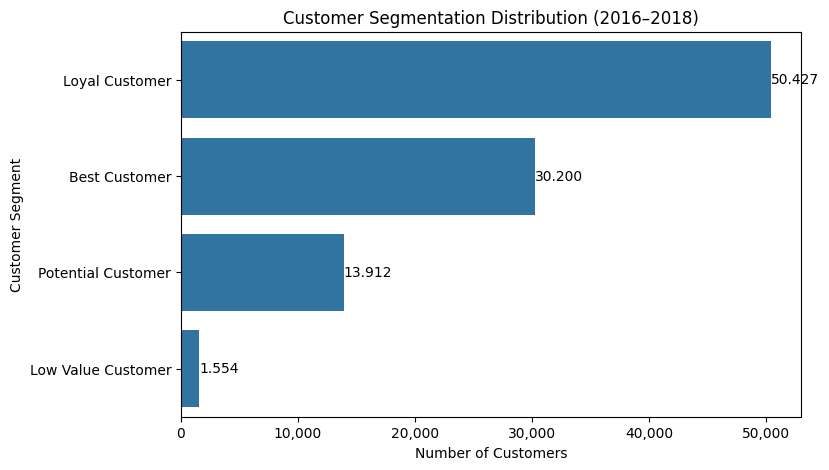

In [59]:
plt.figure(figsize=(8,5))
ax = sns.countplot(
    data=rfm,
    y='segment',
    order=rfm['segment'].value_counts().index,
)

plt.title('Customer Segmentation Distribution (2016–2018)')
plt.xlabel('Number of Customers')
plt.ylabel('Customer Segment')

for p in ax.patches:
    width = p.get_width()  
    ax.annotate(
        f'{int(width):,}'.replace(',', '.'),
        (width, p.get_y() + p.get_height()/2),
        ha='left',
        va='center'
    )

formatter = FuncFormatter(lambda x, _: f'{int(x):,}')
ax.xaxis.set_major_formatter(formatter)

plt.show()

In [60]:
print("Total customer:", rfm['customer_id'].nunique())
print(rfm['segment'].value_counts())
print("Total revenue:", rfm['monetary'].sum())

Total customer: 96093
segment
Loyal Customer        50427
Best Customer         30200
Potential Customer    13912
Low Value Customer     1554
Name: count, dtype: int64
Total revenue: 16008872.120000001


### Pertanyaan 2: Kategori produk apa yang memiliki jumlah transaksi tertinggi selama periode 2016–2018, dan berapa persentase kontribusinya terhadap total penjualan?

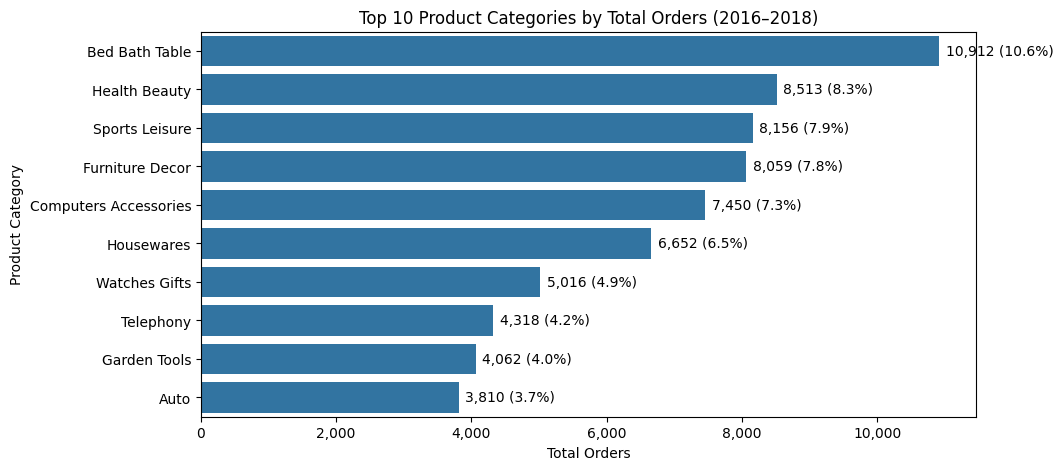

In [61]:
plt.figure(figsize=(10,5))
ax = sns.barplot(
    data=top_10,
    x='order_item_id',
    y='product_category_name_english',
)

plt.title('Top 10 Product Categories by Total Orders (2016–2018)')
plt.xlabel('Total Orders')
plt.ylabel('Product Category')

for i, v in enumerate(top_10['order_item_id']):
    percent = top_10['percentage'].iloc[i]
    ax.text(v + 100, i, f'{v:,} ({percent:.1f}%)', va='center')

formatter = FuncFormatter(lambda x, _: f'{int(x):,}')
ax.xaxis.set_major_formatter(formatter)

plt.show()

### Pertanyaan 3: Bagaimana perbedaan rata-rata rating pelanggan antara pesanan yang dikirim tepat waktu dan terlambat pada periode 2016–2018?

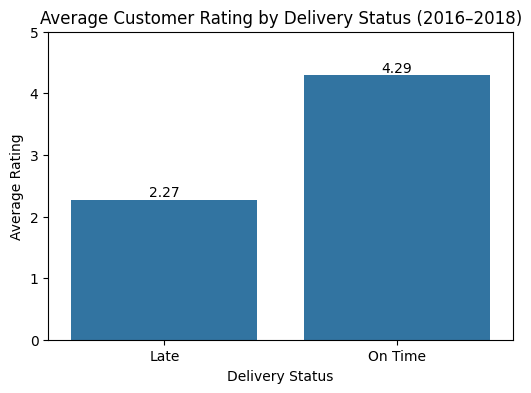

In [62]:
plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=delay_vs_rating,
    x='delivery_status',
    y='review_score',
)

plt.title('Average Customer Rating by Delivery Status (2016–2018)')
plt.xlabel('Delivery Status')
plt.ylabel('Average Rating')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.ylim(0,5)
plt.show()

**Insight:**
- Berdasarkan hasil visualisasi Pertanyaan 1, distribusi pelanggan menunjukkan bahwa Loyal Customer mendominasi (52%), diikuti oleh Best Customer (31%). Hal ini menandakan bahwa mayoritas pelanggan memiliki tingkat retensi yang baik. Namun, keberadaan Potential Customer (14%) menunjukkan adanya peluang untuk meningkatkan frekuensi transaksi agar naik ke segmen loyal
- Visualisasi Pertanyaan 2 menunjukkan bahwa kategori Bed Bath Table menyumbang 10.6% dari total transaksi, diikuti oleh Health Beauty (8.3%) dan Sports Leisure (7.9%). Konsentrasi ini menunjukkan bahwa penjualan terfokus pada beberapa kategori utama, bukan merata
- Berdasarkan visualisasi Pertanyaan 3, terlihat bahwa pengiriman yang terlambat memiliki dampak signifikan terhadap penurunan rating pelanggan. Rata-rata rating untuk pesanan yang terlambat sebesar 2.27, jauh lebih rendah dibandingkan dengan pesanan yang dikirim tepat waktu yang memiliki rata-rata rating sebesar 4.29. Hal ini menunjukkan bahwa keterlambatan pengiriman secara langsung menurunkan kepuasan pelanggan secara drastis

## Conclusion

Berdasarkan analisis data periode 2016–2018, diperoleh beberapa kesimpulan utama:

1. Segmentasi pelanggan menunjukkan bahwa Loyal Customer mendominasi sebesar sekitar 52% (50.427 pelanggan), diikuti oleh Best Customer sebesar 31% (30.200 pelanggan). Hal ini menunjukkan bahwa bisnis memiliki basis pelanggan yang kuat dengan tingkat retensi yang baik. Namun, sekitar 14% pelanggan masih berada pada kategori Potential Customer, yang menunjukkan peluang untuk ditingkatkan melalui strategi pemasaran dan engagement.
2. Kategori produk dengan penjualan tertinggi adalah Bed Bath Table dengan total 11.115 transaksi (10.6%), diikuti oleh Health Beauty (8.3%) dan Sports Leisure (7.9%). Distribusi ini menunjukkan bahwa penjualan terkonsentrasi pada beberapa kategori utama, sehingga perusahaan dapat mengoptimalkan strategi stok, promosi, dan bundling produk pada kategori tersebut.
3. Performa pengiriman memiliki pengaruh signifikan terhadap kepuasan pelanggan. Pesanan yang dikirim tepat waktu memiliki rata-rata rating sebesar 4.29, sedangkan pesanan yang terlambat hanya sebesar 2.27. Selisih sekitar 2 poin ini menunjukkan bahwa ketepatan waktu pengiriman merupakan faktor krusial dalam menjaga pengalaman dan kepuasan pelanggan.

Secara keseluruhan, hasil analisis ini menunjukkan bahwa perusahaan perlu mempertahankan pelanggan loyal, mengoptimalkan kategori produk unggulan, serta meningkatkan performa pengiriman untuk menjaga kepuasan pelanggan dan mendorong pertumbuhan bisnis

In [63]:
all_df.to_csv("dashboard/main_data.csv", index=False)